In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

!pip install yfinance pandas numpy scipy matplotlib seaborn


In [10]:

def fetch_data(ticker, start, end):
    stock_data = yf.download(ticker, start=start, end=end)
    return stock_data



In [11]:
def calculate_metrics(data, ticker):
    # Access the 'Close' prices using MultiIndex
    close_prices = data[('Close', ticker)]
    
    # Calculate daily returns
    data['Daily Return'] = close_prices.pct_change()

    # Absolute Return
    absolute_return = (close_prices.iloc[-1] / close_prices.iloc[0]) - 1

    # ROI
    roi = (close_prices.iloc[-1] - close_prices.iloc[0]) / close_prices.iloc[0]

    # Sharpe Ratio
    mean_return = data['Daily Return'].mean()
    std_dev = data['Daily Return'].std()
    sharpe_ratio = mean_return / std_dev * np.sqrt(252)

    return absolute_return, roi, sharpe_ratio


In [12]:

def compare_performance(stock_metrics, benchmark_metrics):
    comparison = {
        'Metric': ['Absolute Return', 'ROI', 'Sharpe Ratio'],
        'Stock': stock_metrics,
        'S&P 500': benchmark_metrics['^GSPC'],
        'NASDAQ': benchmark_metrics['^IXIC'],
        'Dow Jones': benchmark_metrics['^DJI']
    }
    return pd.DataFrame(comparison)



In [13]:
def plot_performance(comparison_df):
    comparison_df.set_index('Metric', inplace=True)
    comparison_df.plot(kind='bar', figsize=(10, 6))
    plt.title('Stock vs Market Benchmarks Performance')
    plt.ylabel('Metrics')
    plt.xlabel('Performance Metrics')
    plt.show()



In [14]:
# Define stock and market indices
stock_ticker = 'AAPL'
market_indices = ['^GSPC', '^IXIC', '^DJI']
start_date = '2022-01-01'
end_date = '2023-01-01'



In [15]:
# Fetch data
stock_data = fetch_data(stock_ticker, start_date, end_date)
benchmark_data = {index: fetch_data(index, start_date, end_date) for index in market_indices}

# Print columns to verify
print(stock_data.columns)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [16]:

# Calculate metrics
stock_metrics = calculate_metrics(stock_data, stock_ticker)
benchmark_metrics = {index: calculate_metrics(benchmark_data[index], index) for index in market_indices}


In [17]:

# Compare performance
performance_comparison = compare_performance(stock_metrics, benchmark_metrics)
print(performance_comparison)


            Metric     Stock   S&P 500    NASDAQ  Dow Jones
0  Absolute Return -0.281995 -0.199531 -0.338937  -0.093968
1              ROI -0.281995 -0.199531 -0.338937  -0.093968
2     Sharpe Ratio -0.758359 -0.805521 -1.144239  -0.402058


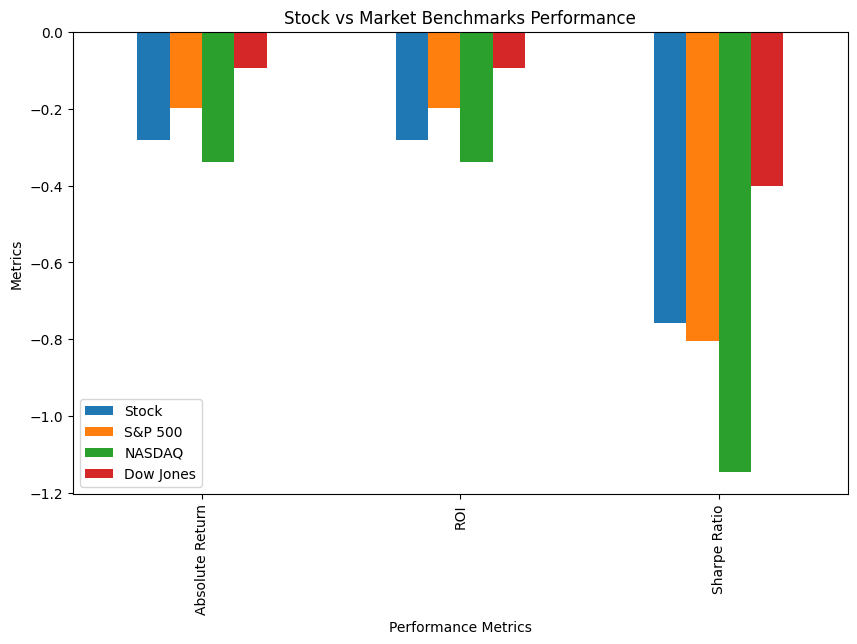

In [18]:

# Plot performance
plot_performance(performance_comparison)


In [20]:

import seaborn as sns




def fetch_data(ticker, start, end):
    stock_data = yf.download(ticker, start=start, end=end)
    return stock_data



In [21]:
def calculate_risk_metrics(data, ticker, confidence_level=0.95):
    # Access the 'Close' prices using MultiIndex
    close_prices = data[('Close', ticker)]
    
    # Calculate daily returns
    daily_returns = close_prices.pct_change().dropna()

    # Calculate VaR
    var = np.percentile(daily_returns, (1 - confidence_level) * 100)

    # Calculate CVaR
    cvar = daily_returns[daily_returns <= var].mean()

    return var, cvar



In [22]:
def compare_risk_metrics(stock_risk_metrics, benchmark_risk_metrics):
    comparison = {
        'Metric': ['VaR', 'CVaR'],
        'Stock': stock_risk_metrics,
        'S&P 500': benchmark_risk_metrics['^GSPC'],
        'NASDAQ': benchmark_risk_metrics['^IXIC'],
        'Dow Jones': benchmark_risk_metrics['^DJI']
    }
    return pd.DataFrame(comparison)



In [23]:
def plot_risk_metrics(comparison_df):
    comparison_df.set_index('Metric', inplace=True)
    comparison_df.plot(kind='bar', figsize=(10, 6))
    plt.title('Stock vs Market Benchmarks Risk Metrics')
    plt.ylabel('Metrics')
    plt.xlabel('Risk Metrics')
    plt.show()



In [24]:
# Define stock and market indices
stock_ticker = 'AAPL'
market_indices = ['^GSPC', '^IXIC', '^DJI']
start_date = '2022-01-01'
end_date = '2023-01-01'



In [25]:
# Fetch data
stock_data = fetch_data(stock_ticker, start_date, end_date)
benchmark_data = {index: fetch_data(index, start_date, end_date) for index in market_indices}


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [26]:

# Calculate risk metrics
stock_risk_metrics = calculate_risk_metrics(stock_data, stock_ticker)
benchmark_risk_metrics = {index: calculate_risk_metrics(benchmark_data[index], index) for index in market_indices}



  Metric     Stock   S&P 500    NASDAQ  Dow Jones
0    VaR -0.037318 -0.026508 -0.034506  -0.020522
1   CVaR -0.045476 -0.033468 -0.042061  -0.027913


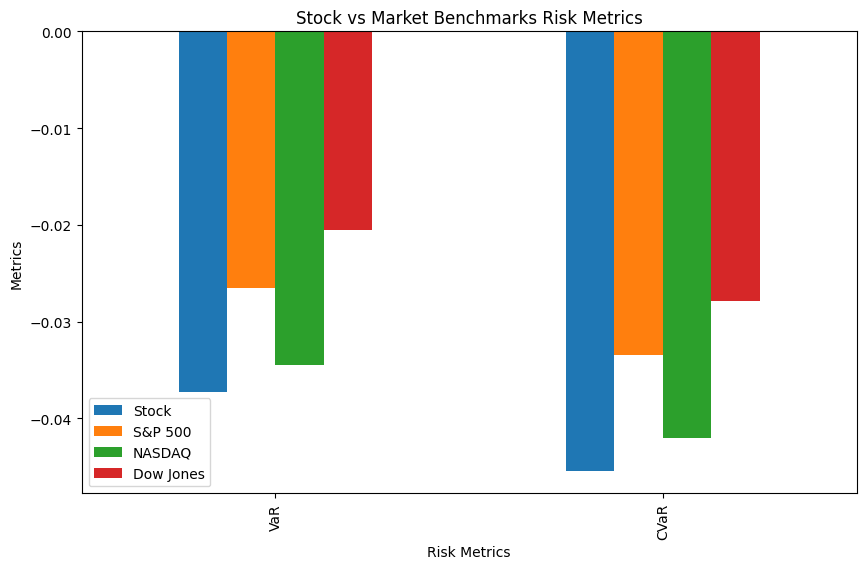

In [27]:
# Compare risk metrics
risk_comparison = compare_risk_metrics(stock_risk_metrics, benchmark_risk_metrics)
print(risk_comparison)

# Plot risk metrics
plot_risk_metrics(risk_comparison)


In [29]:
def fetch_data(ticker, start, end):
    stock_data = yf.download(ticker, start=start, end=end)
    return stock_data

def calculate_risk_metrics(data, ticker, confidence_level=0.95):
    # Access the 'Close' prices using MultiIndex
    close_prices = data[('Close', ticker)]
    
    # Calculate daily returns
    daily_returns = close_prices.pct_change().dropna()

    # Calculate VaR
    var = np.percentile(daily_returns, (1 - confidence_level) * 100)

    # Calculate CVaR
    cvar = daily_returns[daily_returns <= var].mean()

    return var, cvar

def compare_risk_metrics_before_and_during_crash(stock_risk_metrics, stock_risk_metrics_crash, benchmark_risk_metrics, benchmark_risk_metrics_crash):
    comparison = {
        'Metric': ['VaR', 'CVaR'],
        'Before Crash': stock_risk_metrics,
        'During Crash': stock_risk_metrics_crash,
        'S&P 500 Before Crash': benchmark_risk_metrics['^GSPC'],
        'S&P 500 During Crash': benchmark_risk_metrics_crash['^GSPC'],
        'NASDAQ Before Crash': benchmark_risk_metrics['^IXIC'],
        'NASDAQ During Crash': benchmark_risk_metrics_crash['^IXIC'],
        'Dow Jones Before Crash': benchmark_risk_metrics['^DJI'],
        'Dow Jones During Crash': benchmark_risk_metrics_crash['^DJI']
    }
    return pd.DataFrame(comparison)

def plot_risk_metrics_comparison(comparison_df):
    comparison_df.set_index('Metric', inplace=True)
    comparison_df.plot(kind='bar', figsize=(10, 6))
    plt.title('Risk Metrics Before and During Market Crash')
    plt.ylabel('Metrics')
    plt.xlabel('Performance Metrics')
    plt.show()



In [30]:
# Define stock and market indices
stock_ticker = 'AAPL'
market_indices = ['^GSPC', '^IXIC', '^DJI']
start_date = '2007-01-01'
end_date = '2009-12-31'

# Fetch data
stock_data = fetch_data(stock_ticker, start_date, end_date)
benchmark_data = {index: fetch_data(index, start_date, end_date) for index in market_indices}

# Fetch data for the crash period
crash_start = '2008-01-01'
crash_end = '2008-12-31'
stock_data_crash = fetch_data(stock_ticker, crash_start, crash_end)
benchmark_data_crash = {index: fetch_data(index, crash_start, crash_end) for index in market_indices}


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


  Metric  Before Crash  During Crash  S&P 500 Before Crash  \
0    VaR     -0.044911     -0.058252             -0.029468   
1   CVaR     -0.064028     -0.083713             -0.046394   

   S&P 500 During Crash  NASDAQ Before Crash  NASDAQ During Crash  \
0             -0.044418            -0.030652            -0.044080   
1             -0.064591            -0.045775            -0.061021   

   Dow Jones Before Crash  Dow Jones During Crash  
0               -0.026361               -0.039441  
1               -0.041447               -0.057261  


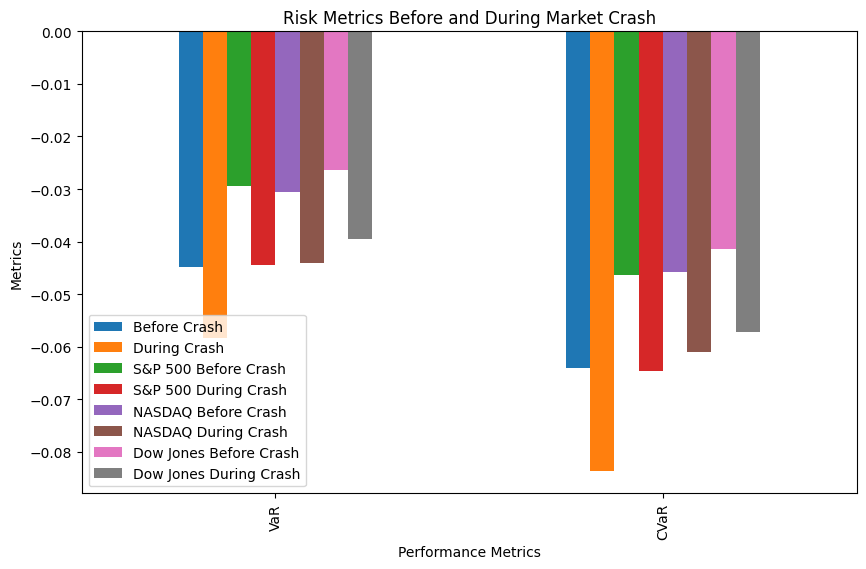

In [31]:

# Calculate risk metrics
stock_risk_metrics = calculate_risk_metrics(stock_data, stock_ticker)
stock_risk_metrics_crash = calculate_risk_metrics(stock_data_crash, stock_ticker)
benchmark_risk_metrics = {index: calculate_risk_metrics(benchmark_data[index], index) for index in market_indices}
benchmark_risk_metrics_crash = {index: calculate_risk_metrics(benchmark_data_crash[index], index) for index in market_indices}

# Compare risk metrics before and during the crash
risk_comparison_crash = compare_risk_metrics_before_and_during_crash(stock_risk_metrics, stock_risk_metrics_crash, benchmark_risk_metrics, benchmark_risk_metrics_crash)
print(risk_comparison_crash)

# Plot risk metrics comparison
plot_risk_metrics_comparison(risk_comparison_crash)
